# Lab 3: Linear Regression on Medical Costs
Using the Kaggle Medical Cost Dataset to predict insurance charges based on factors like age, BMI, and smoking status.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Data Loading

In [2]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Exploratory Data Analysis (EDA)
Visualizing distributions and relationships before modeling.

c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


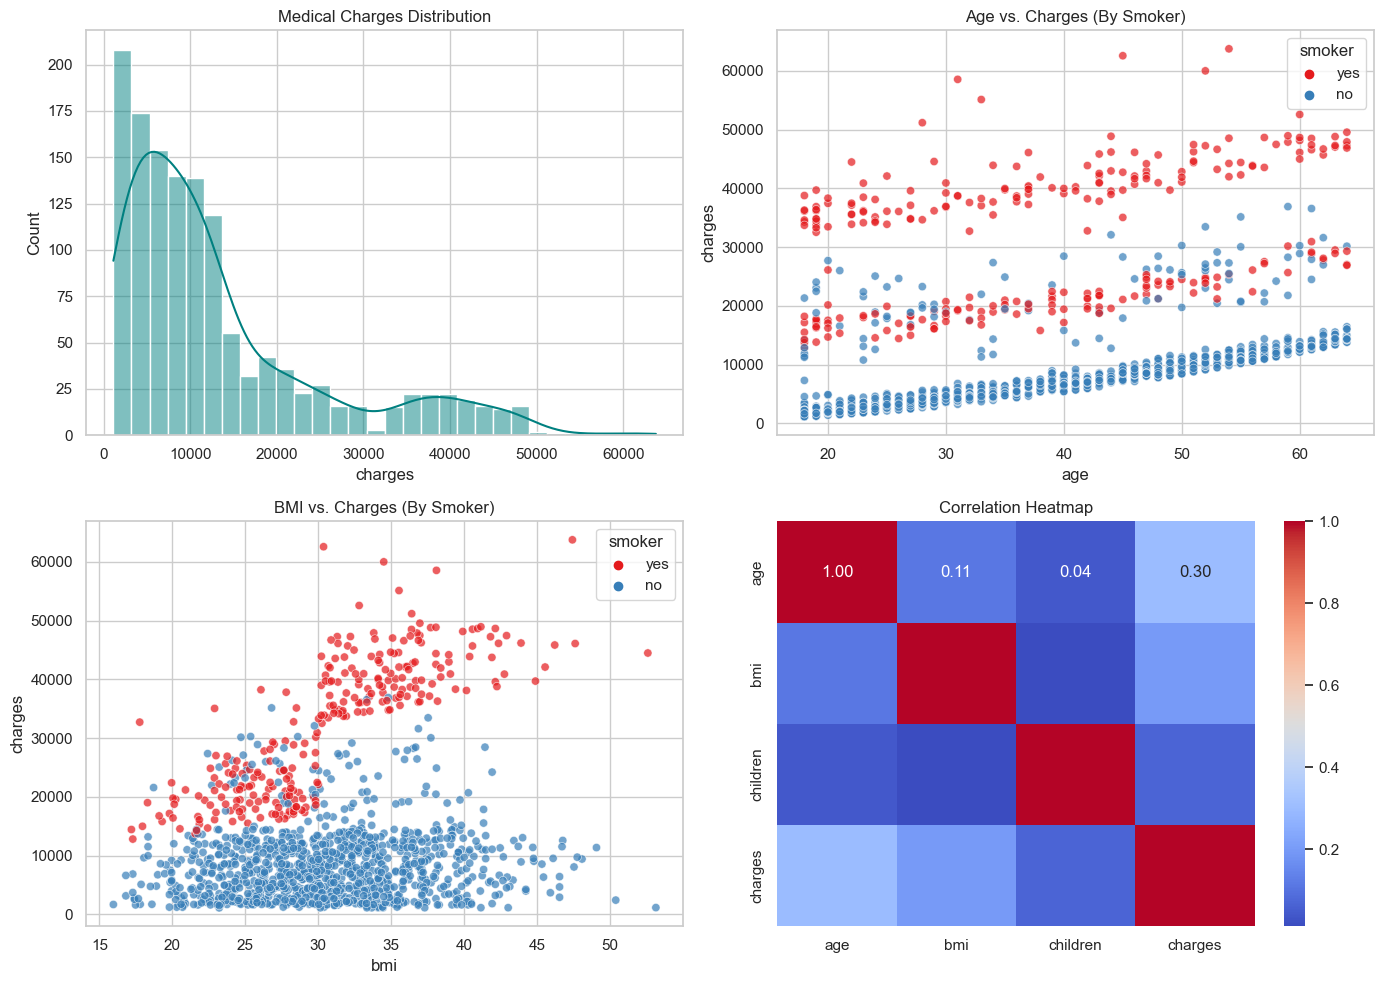

In [3]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['charges'], kde=True, color='teal', bins=30)
plt.title('Medical Charges Distribution')

plt.subplot(2, 2, 2)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='Set1', alpha=0.7)
plt.title('Age vs. Charges (By Smoker)')

plt.subplot(2, 2, 3)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='Set1', alpha=0.7)
plt.title('BMI vs. Charges (By Smoker)')

plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## 3. Preprocessing
To meet lab requirements, I dropped a few BMI values to simulate missing data. I'm using `ColumnTransformer` to impute missing values, scale numbers, and one-hot encode categories.

In [4]:
df_modified = df.copy()
np.random.seed(42)
df_modified.loc[np.random.choice(df.index, 15, replace=False), 'bmi'] = np.nan

X = df_modified.drop('charges', axis=1)
y = df_modified['charges']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, ['age', 'bmi', 'children']),
        ('cat', categorical_transformer, ['sex', 'smoker', 'region'])
    ])

## 4. Modeling (Linear Regression)
Splitting 80/20 for train/test, then fitting the model.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

model = LinearRegression()
model.fit(X_train_prep, y_train)

y_train_pred = model.predict(X_train_prep)
y_test_pred = model.predict(X_test_prep)

## 5. Evaluation & R² Charts
Let's check the metrics and plot **Actual vs Predicted** charges to visually represent our $R^2$ score.

--- Training Data ---
MAE: 4208.23 | MSE: 37277681.70
RMSE: 6105.55 | R²: 0.7417

--- Testing Data ---
MAE: 4203.10 | MSE: 34263978.48
RMSE: 5853.54 | R²: 0.7793



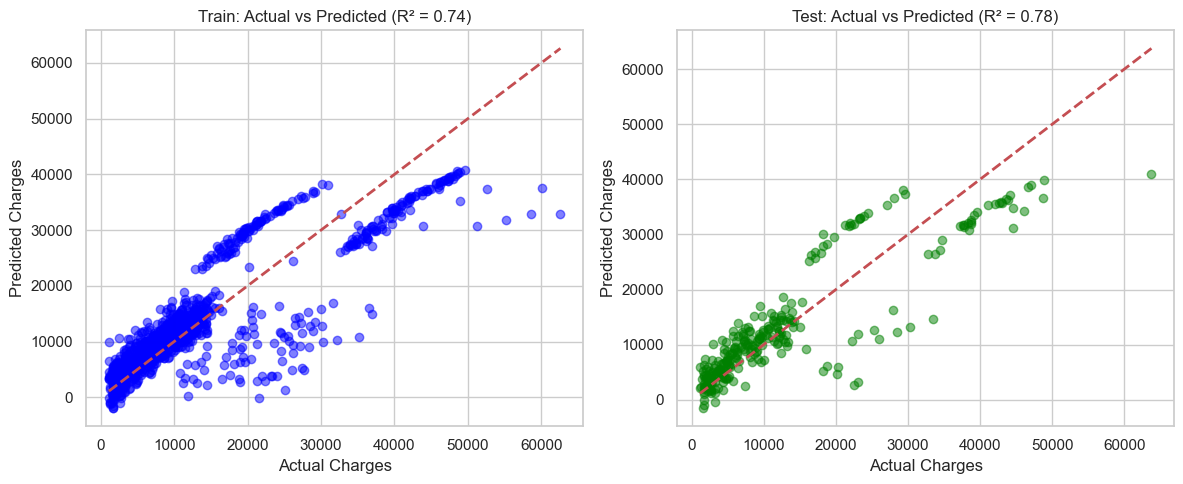

In [6]:
def print_evaluation(y_true, y_pred, label):
    print(f"--- {label} ---")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f} | MSE: {mean_squared_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f} | R²: {r2_score(y_true, y_pred):.4f}\n")

print_evaluation(y_train, y_train_pred, "Training Data")
print_evaluation(y_test, y_test_pred, "Testing Data")

# --- R2 Charts (Actual vs Predicted) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.title(f"Train: Actual vs Predicted (R² = {r2_score(y_train, y_train_pred):.2f})")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Test: Actual vs Predicted (R² = {r2_score(y_test, y_test_pred):.2f})")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.tight_layout()
plt.show()

### Overfitting Analysis
- **Result:** The model generalized well. The Train $R^2$ (~0.74) and Test $R^2$ (~0.78) are very similar, meaning it learned the underlying trends rather than memorizing the data.
- **If it had overfitted, I would:**
  1. Remove irrelevant features (Feature Selection).
  2. Use K-Fold Cross-Validation.
  3. Apply Regularization techniques like Ridge or Lasso regression.